# Convergent Nozzle Design: Hydrogen Test Engine (Sheet Metal)

**Design rationale:** With a turbocharger pressure ratio of 3.5, a converging-diverging nozzle is not worthwhile. The divergent section would add only ~5% thrust at the design point and would overexpand under any throttling. A convergent nozzle is the right call because:

1. The throat chokes at $M=1$, setting $\dot{m}$ purely from upstream conditions.
2. Simpler to fabricate from sheet metal.
3. Any supersonic expansion happens outside the nozzle as an underexpanded jet.

**Construction constraint:** rolled/welded sheet metal. This matters because you cannot achieve the $C_d \approx 0.98$ of a machined nozzle. Realistic values:

- $C_d = 0.85\text{-}0.90$ for a rolled/welded conical convergent with a moderate inlet radius.
- $C_d = 0.80\text{-}0.85$ for a sharp-bend folded sheet.
- $C_d = 0.90\text{-}0.93$ at best with a carefully rolled curved profile.

We use **$C_d = 0.88$** as a realistic sheet-metal design value. This accounts for wall roughness, imperfect inlet curvature, weld-bead flow disturbances, and axisymmetry tolerances.

**Operating point:**
- Combustor pressure ratio: 3.5
- Equivalence ratio: $\phi = 0.316$ (lean)
- Reactants pre-heat: 462 K
- Design mass flow: 0.56699 kg/s

Governing relation for choked flow at the throat:

$$\dot{m} = C_d \, A^* \, P_0 \sqrt{\frac{\gamma}{R T_0}} \left(\frac{2}{\gamma+1}\right)^{\frac{\gamma+1}{2(\gamma-1)}}$$


In [1]:
import cantera as ct
import numpy as np
import matplotlib.pyplot as plt

# --- Operating point ---
PR          = 3.5            # turbocharger pressure ratio
P_ambient   = 101_325        # Pa
P0          = PR * P_ambient # Pa, combustor stagnation pressure
phi         = 0.316          # equivalence ratio
T_reactants = 462.24         # K, post-compression reactants

# --- Combustor equilibrium ---
gas = ct.Solution('gri30.yaml')
gas.set_equivalence_ratio(phi, 'H2', 'O2:1, N2:3.76')
gas.TP = T_reactants, P0
gas.equilibrate('HP')

T0        = gas.T
h0        = gas.enthalpy_mass
s0        = gas.entropy_mass
gamma_eff = gas.cp / gas.cv
R_eff     = ct.gas_constant / gas.mean_molecular_weight

print(f"Combustor stagnation conditions:")
print(f"  P0     = {P0/1e5:.3f} bar")
print(f"  T0     = {T0:.1f} K")
print(f"  gamma  = {gamma_eff:.4f}")
print(f"  R      = {R_eff:.2f} J/kg/K")
print(f"  PR     = {PR:.2f}")


Combustor stagnation conditions:
  P0     = 3.546 bar
  T0     = 1369.7 K
  gamma  = 1.2998
  R      = 304.49 J/kg/K
  PR     = 3.50


## Check that the nozzle will choke

The flow chokes at the throat if:

$$\frac{P_0}{P_\infty} \geq \left(\frac{\gamma+1}{2}\right)^{\frac{\gamma}{\gamma-1}}$$


In [2]:
PR_critical = ((gamma_eff + 1) / 2) ** (gamma_eff / (gamma_eff - 1))

print(f"Critical pressure ratio (choke): {PR_critical:.3f}")
print(f"Operating pressure ratio       : {PR:.3f}")
if PR > PR_critical:
    print("--> Nozzle is CHOKED. Throat sits at M=1.")
else:
    print("--> Nozzle is NOT choked. Subsonic throughout.")


Critical pressure ratio (choke): 1.832
Operating pressure ratio       : 3.500
--> Nozzle is CHOKED. Throat sits at M=1.


## Throat state

Find the pressure at which local velocity equals local sound speed using Cantera for real-gas, variable-$\gamma$ expansion.


In [3]:
from scipy.optimize import brentq

def find_throat_state(gas_inlet):
    s0 = gas_inlet.entropy_mass
    h0 = gas_inlet.enthalpy_mass
    X0 = gas_inlet.X

    def mach_minus_one(P_t):
        g = ct.Solution('gri30.yaml')
        g.TPX = gas_inlet.T, P_t, X0
        g.SP  = s0, P_t
        g.equilibrate('SP')
        V = np.sqrt(max(2 * (h0 - g.enthalpy_mass), 0.0))
        return V / g.sound_speed - 1.0

    P_low  = gas_inlet.P * 0.30
    P_high = gas_inlet.P * 0.95
    P_t    = brentq(mach_minus_one, P_low, P_high, xtol=1.0, rtol=1e-6)

    g_t = ct.Solution('gri30.yaml')
    g_t.TPX = gas_inlet.T, P_t, X0
    g_t.SP  = s0, P_t
    g_t.equilibrate('SP')
    return g_t, P_t

gas_throat, P_throat = find_throat_state(gas)

T_throat   = gas_throat.T
rho_throat = gas_throat.density
V_throat   = np.sqrt(2 * (h0 - gas_throat.enthalpy_mass))
a_throat   = gas_throat.sound_speed

print(f"Throat conditions:")
print(f"  P_throat     = {P_throat/1e5:.3f} bar")
print(f"  T_throat     = {T_throat:.1f} K")
print(f"  rho_throat   = {rho_throat:.3f} kg/m^3")
print(f"  V_throat     = {V_throat:.1f} m/s  (sound speed = {a_throat:.1f} m/s)")
print(f"  P*/P0 ratio  = {P_throat/P0:.4f}  (ideal: {1/PR_critical:.4f})")


Throat conditions:
  P_throat     = 1.928 bar
  T_throat     = 1188.9 K
  rho_throat   = 0.533 kg/m^3
  V_throat     = 688.5 m/s  (sound speed = 688.5 m/s)
  P*/P0 ratio  = 0.5437  (ideal: 0.5458)


## Size the throat from target mass flow

The throat area from continuity:

$$A^* = \frac{\dot{m}}{\rho^* V^*}$$

For sheet metal fabrication we apply $C_d = 0.88$. The geometric area is larger than the effective (ideal) area:

$$A^*_{\text{geometric}} = \frac{A^*_{\text{effective}}}{C_d}$$

**Consequence:** dropping $C_d$ from 0.98 (machined) to 0.88 (sheet metal) increases the required geometric throat area by $0.98/0.88 \approx 11\%$, so the throat diameter grows by $\sqrt{1.11} \approx 5.4\%$.


In [4]:
mdot = 0.56699   # kg/s, design mass flow
Cd   = 0.88      # sheet metal, rolled/welded conical convergent

# Effective (ideal) throat area from continuity
A_throat_eff = mdot / (rho_throat * V_throat)

# Geometric throat area corrected for Cd
A_throat_geom = A_throat_eff / Cd
D_throat      = 2 * np.sqrt(A_throat_geom / np.pi)

# Compare to what a machined (Cd=0.98) throat would need
D_throat_machined = 2 * np.sqrt((A_throat_eff / 0.98) / np.pi)

print(f"Throat sizing:")
print(f"  Effective throat area     = {A_throat_eff*1e6:.2f} mm^2")
print(f"  Geometric throat area     = {A_throat_geom*1e6:.2f} mm^2  (Cd = {Cd})")
print(f"  Throat diameter           = {D_throat*1000:.2f} mm")
print(f"  (vs machined Cd=0.98)     = {D_throat_machined*1000:.2f} mm")
print(f"  Sheet-metal penalty       = +{(D_throat/D_throat_machined - 1)*100:.1f}% diameter")


Throat sizing:
  Effective throat area     = 1546.03 mm^2
  Geometric throat area     = 1756.85 mm^2  (Cd = 0.88)
  Throat diameter           = 47.30 mm
  (vs machined Cd=0.98)     = 44.82 mm
  Sheet-metal penalty       = +5.5% diameter


## Exit conditions and thrust

The throat IS the exit for a convergent nozzle. Exit is choked at $M=1$; further expansion happens outside as an underexpanded jet.

$$F = \dot{m} V^* + (P^* - P_\infty) A^*$$

At PR = 3.5 the underexpansion is more significant than at PR = 3.0, so a larger fraction of total thrust comes from the pressure-thrust term, which is less efficient than momentum thrust.


In [5]:
F_momentum = mdot * V_throat
F_pressure = (P_throat - P_ambient) * A_throat_geom
F_total    = F_momentum + F_pressure

g0    = 9.80665
I_sp  = F_total / (mdot * g0)
V_eff = F_total / mdot

print(f"Thrust breakdown:")
print(f"  Momentum thrust  = {F_momentum:.1f} N")
print(f"  Pressure thrust  = {F_pressure:.1f} N")
print(f"  Total thrust     = {F_total:.1f} N")
print(f"  Pressure/total   = {F_pressure/F_total*100:.1f} %")
print()
print(f"Performance:")
print(f"  Effective V_e    = {V_eff:.1f} m/s")
print(f"  Specific impulse = {I_sp:.1f} s")
print()
print(f"Underexpansion ratio P*/P_inf = {P_throat/P_ambient:.3f}")
print("(jet continues expanding externally into Prandtl-Meyer fan)")


Thrust breakdown:
  Momentum thrust  = 390.4 N
  Pressure thrust  = 160.8 N
  Total thrust     = 551.1 N
  Pressure/total   = 29.2 %

Performance:
  Effective V_e    = 972.0 m/s
  Specific impulse = 99.1 s

Underexpansion ratio P*/P_inf = 1.903
(jet continues expanding externally into Prandtl-Meyer fan)


## Convergent contour (sheet-metal-compatible)

Geometry rules adjusted for rolled/welded sheet metal construction. The fillet radii are smaller than the machined-design defaults because you cannot physically roll tight fillets in sheet metal without specialist equipment (deep drawing, hydroforming).

- **Inlet diameter:** $D_\text{inlet} \approx 2 \cdot D_\text{throat}$ (area contraction ~4).
- **Convergence half-angle:** 25 deg. Shallower than a machined 28 deg because sheet metal surface roughness makes separation worse, and shallower taper is more forgiving.
- **Inlet radius of curvature:** $0.30 \cdot D_\text{throat}$ (reduced from 0.75). Rollable with a bead roller or formed over a mandrel.
- **Throat fillet radius:** $0.20 \cdot D_\text{throat}$ (reduced from 0.50). In practice you will likely approximate this with a short straight transition anyway.
- **Throat land:** $0.50 \cdot D_\text{throat}$ (reduced from 0.75). Shorter means less rolling precision required.

Contour built from three arcs and a straight taper:

1. **Inlet fillet arc** (radius $R_\text{inlet}$).
2. **Conical taper** at the convergence half-angle.
3. **Throat fillet arc** (radius $R_\text{throat}$).
4. **Throat land** (straight, constant area).


In [6]:
def convergent_contour(D_throat,
                       contraction_ratio = 2.0,
                       half_angle_deg    = 25.0,   # shallower for sheet metal
                       R_inlet_factor    = 0.30,   # sheet metal cannot roll tight fillets
                       R_throat_factor   = 0.20,   # likewise
                       L_throat_factor   = 0.50,   # shorter throat land, easier to roll
                       n_points          = 400):
    """
    Build a convergent nozzle contour from inlet plane to throat exit.

    Sheet-metal-friendly defaults: shallower taper and looser fillets than a
    machined design.

    Geometry order along flow direction:
      inlet fillet arc -> conical taper -> throat fillet arc -> throat land
    All lengths in metres; diameters in metres.
    """
    r_throat = D_throat / 2.0
    r_inlet  = r_throat * contraction_ratio
    theta    = np.radians(half_angle_deg)
    R_in     = R_inlet_factor  * D_throat
    R_th     = R_throat_factor * D_throat
    L_th     = L_throat_factor * D_throat

    # Segment 4: throat land, x=0 at throat start
    x4 = np.linspace(0.0, L_th, max(int(n_points * 0.1), 20))
    r4 = np.full_like(x4, r_throat)

    # Segment 3: throat fillet arc, tangent to throat land at (0, r_throat)
    cx3, cy3 = 0.0, r_throat + R_th
    a_end3   = -np.pi / 2.0
    a_start3 = a_end3 - theta
    alpha3   = np.linspace(a_start3, a_end3, max(int(n_points * 0.2), 40))
    x3 = cx3 + R_th * np.cos(alpha3)
    r3 = cy3 + R_th * np.sin(alpha3)
    x3_start, r3_start = x3[0], r3[0]

    # Segment 2: conical taper (upstream of throat arc)
    r_taper_up_end = r_inlet - R_in * (1.0 - np.cos(theta))
    dr = r_taper_up_end - r3_start
    dx = dr / np.tan(theta)
    x_taper_start = x3_start - dx
    r_taper_start = r_taper_up_end

    x2 = np.linspace(x_taper_start, x3_start, max(int(n_points * 0.4), 80))
    r2 = r3_start + (x3_start - x2) * np.tan(theta)

    # Segment 1: inlet fillet arc (horizontal tangent at inlet plane)
    cx1 = x_taper_start - R_in * np.sin(theta)
    cy1 = r_inlet - R_in
    a_start1 = np.pi / 2.0              # top of circle: tangent horizontal
    a_end1   = np.pi / 2.0 - theta      # tangent matches taper slope
    alpha1   = np.linspace(a_start1, a_end1, max(int(n_points * 0.3), 60))
    x1 = cx1 + R_in * np.cos(alpha1)
    r1 = cy1 + R_in * np.sin(alpha1)

    x = np.concatenate([x1, x2[1:], x3[1:], x4[1:]])
    r = np.concatenate([r1, r2[1:], r3[1:], r4[1:]])
    x = x - x[0]  # shift inlet to x=0

    geom = {
        "D_throat"       : D_throat,
        "D_inlet"        : 2 * r_inlet,
        "half_angle_deg" : half_angle_deg,
        "R_inlet"        : R_in,
        "R_throat"       : R_th,
        "L_throat_land"  : L_th,
        "L_total"        : x[-1],
    }
    return x, r, geom


x, r, geom = convergent_contour(D_throat)

D_turbine_outlet = 0.120  # metres, measure your actual unit, expect 115-130mm range

# Then recompute:
x, r, geom = convergent_contour(
    D_throat,
    contraction_ratio = D_turbine_outlet / D_throat
)

print("Convergent nozzle geometry (sheet metal):")
print(f"  Throat diameter      = {geom['D_throat']*1000:.2f} mm")
print(f"  Inlet diameter       = {geom['D_inlet']*1000:.2f} mm")
print(f"  Half-angle           = {geom['half_angle_deg']:.1f} deg")
print(f"  Inlet fillet radius  = {geom['R_inlet']*1000:.2f} mm")
print(f"  Throat fillet radius = {geom['R_throat']*1000:.2f} mm")
print(f"  Throat land length   = {geom['L_throat_land']*1000:.2f} mm")
print(f"  Total axial length   = {geom['L_total']*1000:.2f} mm")


Convergent nozzle geometry (sheet metal):
  Throat diameter      = 47.30 mm
  Inlet diameter       = 120.00 mm
  Half-angle           = 25.0 deg
  Inlet fillet radius  = 14.19 mm
  Throat fillet radius = 9.46 mm
  Throat land length   = 23.65 mm
  Total axial length   = 106.85 mm


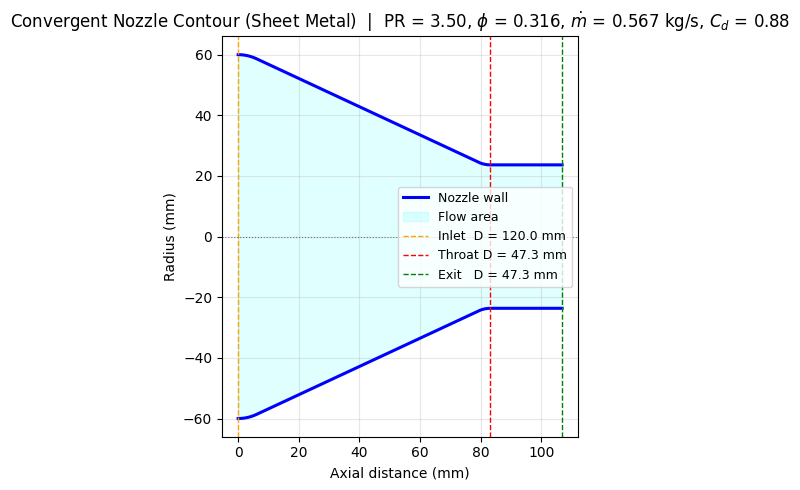

In [7]:
x_mm = x * 1000
r_mm = r * 1000
L_mm = x_mm[-1]

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(x_mm,  r_mm, 'b-', linewidth=2.2, label='Nozzle wall')
ax.plot(x_mm, -r_mm, 'b-', linewidth=2.2)
ax.fill_between(x_mm, -r_mm, r_mm, alpha=0.12, color='cyan', label='Flow area')

ax.axvline(x=0, color='orange', linestyle='--', linewidth=1.0,
           label=f'Inlet  D = {geom["D_inlet"]*1000:.1f} mm')

r_throat_mm = geom['D_throat']/2*1000
idx_throat = np.argmin(np.abs(r_mm - r_throat_mm))
x_throat_mm = x_mm[idx_throat]
ax.axvline(x=x_throat_mm, color='red', linestyle='--', linewidth=1.0,
           label=f'Throat D = {geom["D_throat"]*1000:.1f} mm')

ax.axvline(x=L_mm, color='green', linestyle='--', linewidth=1.0,
           label=f'Exit   D = {geom["D_throat"]*1000:.1f} mm')

ax.axhline(0, color='k', linestyle=':', linewidth=0.8, alpha=0.5)

ax.set_xlabel('Axial distance (mm)')
ax.set_ylabel('Radius (mm)')
ax.set_title(f'Convergent Nozzle Contour (Sheet Metal)  |  '
             f'PR = {PR:.2f}, $\\phi$ = {phi}, $\\dot{{m}}$ = {mdot:.3f} kg/s, '
             f'$C_d$ = {Cd}')
ax.legend(loc='center right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()


## Export contour coordinates

CSV for general use; tab-separated TXT for SolidWorks (Curves > Curve Through XYZ Points).


In [8]:
import pandas as pd

df = pd.DataFrame({
    "x_mm": x_mm,
    "r_mm": r_mm,
    "x_m" : x,
    "r_m" : r,
})
df.to_csv("convergent_nozzle_contour.csv", index=False)

np.savetxt("convergent_nozzle_for_sw.txt",
           np.column_stack([x_mm, r_mm, np.zeros_like(x_mm)]),
           fmt="%.4f", delimiter="\t")

print("Exported:")
print("  convergent_nozzle_contour.csv")
print("  convergent_nozzle_for_sw.txt  (for SolidWorks Curve Through XYZ Points)")
print(f"  Total points: {len(x)}")


Exported:
  convergent_nozzle_contour.csv
  convergent_nozzle_for_sw.txt  (for SolidWorks Curve Through XYZ Points)
  Total points: 397


## Summary

| Quantity | Value |
|---|---|
| Pressure ratio | 3.5 |
| Combustor $T_0$ | ~1370 K |
| Throat $M$ | 1.0 (choked) |
| Discharge coefficient $C_d$ | **0.88 (sheet metal)** |
| Contraction ratio $D_i/D^*$ | 2.0 |
| Convergence half-angle | 25 deg |
| Inlet fillet | $0.30 D^*$ |
| Throat fillet | $0.20 D^*$ |
| Throat land | $0.50 D^*$ |

### Material selection warning

Stainless sheet (304/316) loses significant strength above ~900 K and creeps at elevated temperature. Your stagnation temperature is 1370 K. The metal temperature depends on dwell time and cooling, but:

- **Short-duration test firings (seconds to tens of seconds):** 304/316 stainless sheet is acceptable. Thermal mass absorbs the heat before the wall reaches dangerous temperatures.
- **Sustained operation (minutes):** use **Inconel 625** or **Hastelloy X** sheet. These retain useful strength to ~1250 K. Inconel sheet rolls, but it work-hardens aggressively; weld it with appropriate filler (ERNiCrMo-3 for Inconel 625) and consider solution annealing the finished part.
- **Continuous operation:** active cooling is mandatory regardless of material. Film cooling or regen cooling, depending on what the turbocharger pressure budget allows.
